In [1]:
import mujoco
import mediapy as media
import numpy as np
import mujoco.viewer

In [143]:
xml = '../third_party/franka_emika_panda/scene.xml'
model = mujoco.MjModel.from_xml_path(xml)
data = mujoco.MjData(model)

In [144]:
camera = mujoco.MjvCamera()
mujoco.mjv_defaultFreeCamera(model, camera)
camera.distance = 2.5

""

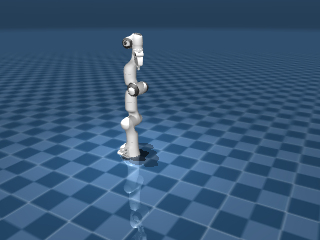

In [145]:
mujoco.mj_forward(model, data)
with mujoco.Renderer(model) as renderer:
    renderer.update_scene(data, camera=camera)
    media.show_image(renderer.render())

In [146]:
# enable joint visualization option:
scene_option = mujoco.MjvOption()
scene_option.flags[mujoco.mjtVisFlag.mjVIS_JOINT] = True

duration = 3.8  # (seconds)
framerate = 60  # (Hz)

# Simulate and display video.
frames = []
mujoco.mj_resetData(model, data)
with mujoco.Renderer(model) as renderer:
  while data.time < duration:
    mujoco.mj_step(model, data)
    if len(frames) < data.time * framerate:
      renderer.update_scene(data, scene_option=scene_option, camera=camera)
      pixels = renderer.render()
      frames.append(pixels)

media.show_video(frames, fps=framerate)

This browser does not support the video tag.


In [147]:
duration = 3
framerate = 60
frames = []
mujoco.mj_resetData(model, data)

# Define target position
target_qpos = np.array([1, -0.785, 0, -2.356, 0, 1.571, 0.785, 0.23])  # Example target joint positions

with mujoco.Renderer(model) as renderer:
    while data.time < duration:
        # Set control target
        data.ctrl[:] = target_qpos
        mujoco.mj_step(model, data)
        
        if len(frames) < data.time * framerate:
            renderer.update_scene(data, camera=camera)
            frames.append(renderer.render())

media.show_video(frames, fps=framerate)

This browser does not support the video tag.


In [169]:
#Put a position of the joints to get a test point
pi = np.pi
data.qpos = [3*pi/2, -pi/2, pi/2, 3*pi/2, 3*pi/2, 0, 0, 0, 0]

#Inititial joint position
qpos0 = data.qpos.copy()

#Step the simulation.
mujoco.mj_forward(model, data)

#Use the last piece as an "end effector" to get a test point in cartesian coordinates
target = data.body('hand').xpos.copy()

In [149]:
#get the name of the joints and its limits
for j in range(len(data.qpos)):
    print("name part =>", data.jnt(j).name, "\n", 
          "limit =>", model.jnt_range[j], "\n")

name part => joint1 
 limit => [-2.8973  2.8973] 

name part => joint2 
 limit => [-1.7628  1.7628] 

name part => joint3 
 limit => [-2.8973  2.8973] 

name part => joint4 
 limit => [-3.0718 -0.0698] 

name part => joint5 
 limit => [-2.8973  2.8973] 

name part => joint6 
 limit => [-0.0175  3.7525] 

name part => joint7 
 limit => [-2.8973  2.8973] 

name part => finger_joint1 
 limit => [0.   0.04] 

name part => finger_joint2 
 limit => [0.   0.04] 



Results
testing point => [0.3595 0.3985 0.421 ]
Gradient Descent result => [0.49882988 0.1323893  0.5940108 ] 



Testing point,Gradient Descent result

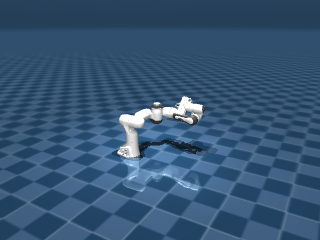
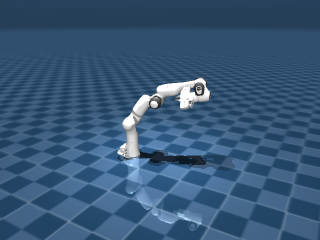

In [170]:
class GradientDescentIK:
    
    def __init__(self, model, data, step_size, tol, alpha, jacp, jacr):
        self.model = model
        self.data = data
        self.step_size = step_size
        self.tol = tol
        self.alpha = alpha
        self.jacp = jacp
        self.jacr = jacr
    
    def check_joint_limits(self, q):
        """Check if the joints is under or above its limits"""
        for i in range(len(q)):
            q[i] = max(self.model.jnt_range[i][0], min(q[i], self.model.jnt_range[i][1]))

    #Gradient Descent pseudocode implementation
    def calculate(self, goal, init_q, body_id):
        """Calculate the desire joints angles for goal"""
        self.data.qpos = init_q
        mujoco.mj_forward(self.model, self.data)
        current_pose = self.data.body(body_id).xpos
        error = np.subtract(goal, current_pose)

        while (np.linalg.norm(error) >= self.tol):
            #calculate jacobian
            mujoco.mj_jac(self.model, self.data, self.jacp, self.jacr, goal, body_id)
            #calculate gradient
            grad = self.alpha * self.jacp.T @ error
            #compute next step
            self.data.qpos += self.step_size * grad
            #check joint limits
            self.check_joint_limits(self.data.qpos)
            #compute forward kinematics
            mujoco.mj_forward(self.model, self.data) 
            #calculate new error
            error = np.subtract(goal, self.data.body(body_id).xpos)        

    
#Init variables.
body_id = model.body('hand').id
jacp = np.zeros((3, model.nv)) #translation jacobian
jacr = np.zeros((3, model.nv)) #rotational jacobian
goal = [0.49, 0.13, 0.59]
step_size = 0.5
tol = 0.01
alpha = 0.5
init_q = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

ik = GradientDescentIK(model, data, step_size, tol, alpha, jacp, jacr)

#Get desire point
mujoco.mj_resetDataKeyframe(model, data, 1) #reset qpos to initial value
ik.calculate(goal, init_q, body_id) #calculate the q angles

result = data.qpos.copy()

#Plot results
print("Results")
data.qpos = qpos0
mujoco.mj_forward(model, data)
with mujoco.Renderer(model) as renderer:
    renderer.update_scene(data, camera)
    target_plot = renderer.render()

data.qpos = result
mujoco.mj_forward(model, data)
result_point = data.body('hand').xpos
with mujoco.Renderer(model) as renderer:
    renderer.update_scene(data, camera)
    result_plot = renderer.render()

print("testing point =>", target)
print("Gradient Descent result =>", result_point, "\n")

images = {
    'Testing point': target_plot,
    'Gradient Descent result': result_plot,
}

media.show_images(images)

In [151]:
#Video Setup
DURATION = 4 #(seconds)
FRAMERATE = 60 #(Hz)
frames = []

#Reset state and time.
mujoco.mj_resetData(model, data)

#Init position.
# pi = np.pi
# data.qpos = [3*pi/2, -pi/2, pi/2, 3*pi/2, 3*pi/2, 0] #ENABLE if you want test circle

#Init parameters
jacp = np.zeros((3, model.nv)) #translation jacobian
jacr = np.zeros((3, model.nv)) #rotational jacobian
step_size = 0.5
tol = 0.01
alpha = 0.5
damping = 0.15

#Get error.
end_effector_id = model.body('hand').id #"End-effector we wish to control.
current_pose = data.body(end_effector_id).xpos #Current pose

goal = [0.79, 0.13, 0.59] #Desire position

error = np.subtract(goal, current_pose) #Init Error

def check_joint_limits(q):
    """Check if the joints is under or above its limits"""
    for i in range(len(q)):
        q[i] = max(model.jnt_range[i][0], min(q[i], model.jnt_range[i][1]))

def circle(t: float, r: float, h: float, k: float, f: float) -> np.ndarray:
    """Return the (x, y) coordinates of a circle with radius r centered at (h, k)
    as a function of time t and frequency f."""
    x = r * np.cos(2 * np.pi * f * t) + h
    y = r * np.sin(2 * np.pi * f * t) + k
    z = 0.5
    return np.array([x, y, z])

#Simulate
while data.time < DURATION:
    
    goal = circle(data.time, 0.1, 0.5, 0.0, 0.5) #ENABLE to test circle.
    
    if (np.linalg.norm(error) >= tol):
        #Calculate jacobian
        mujoco.mj_jac(model, data, jacp, jacr, goal, end_effector_id)
        #Calculate delta of joint q
        n = jacp.shape[1]
        I = np.identity(n)
        product = jacp.T @ jacp + damping * I

        if np.isclose(np.linalg.det(product), 0):
            j_inv = np.linalg.pinv(product) @ jacp.T
        else:
            j_inv = np.linalg.inv(product) @ jacp.T

        delta_q = j_inv @ error

        #Compute next step
        q = data.qpos.copy()
        q += step_size * delta_q
        
        #Check limits
        check_joint_limits(data.qpos)
        
        #Set control signal
        data.ctrl = q[:8]
        #Step the simulation.
        mujoco.mj_step(model, data)

        error = np.subtract(goal, data.body(end_effector_id).xpos)
    
    #Render and save frames.
    if len(frames) < data.time * FRAMERATE:
        with mujoco.Renderer(model) as renderer:
            renderer.update_scene(data)
            pixels = renderer.render()
        frames.append(pixels)
        
#Display video.
media.show_video(frames, fps=FRAMERATE)

This browser does not support the video tag.


IK solutions: [[nan, nan, nan, nan, nan, nan, nan], [nan, nan, nan, nan, nan, nan, nan], [-0.03598298287658433, 0.7306462046850329, 0.10036794677048186, -0.5280344384965021, -0.07036143207768628, 1.2569020747778317, 0.7], [nan, nan, nan, nan, nan, nan, nan]]


Original Start Position

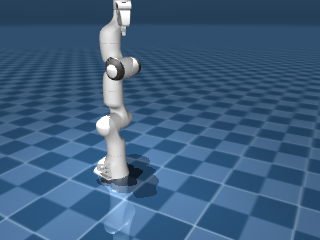

IK (End) Position

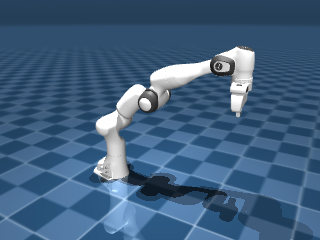

This browser does not support the video tag.


In [152]:
import numpy as np
import franka_ik

x, y, z = 0.7, 0.0, 0.5 
O_T_EE = np.array([
    [1,  0,  0, 0],
    [0, 0.2, 0, 0],
    [0,  0, -1, 0],
    [0,  0,  0, 1]
])
O_T_EE[:3, 3] = [x, y, z]
O_T_EE_array = O_T_EE.T.flatten().tolist()

q7 = 0.7 
data.qpos[7] = 0.0  # Set gripper to closed (or 0.04 for open)
q_actual_array = [0.0] * 7
solutions = franka_ik.franka_IK_EE(O_T_EE_array, q7, q_actual_array)
print("IK solutions:", solutions)

# Find all valid solutions
valid_solution = []
for sol in solutions:
    if not any(np.isnan(sol)):
        valid_solution.append(sol)

# Create a renderer
renderer = mujoco.Renderer(model)

# Render start position
# Reset to default (all zeros) for the arm joints
default_qpos = np.zeros(7)
data.qpos[:7] = default_qpos
mujoco.mj_forward(model, data)
renderer.update_scene(data)
img_start = renderer.render()
media.show_image(img_start, title="Original Start Position")

# Render end position(s) from IK solutions
for sol in valid_solution:
    data.qpos[:7] = sol
    mujoco.mj_forward(model, data)
    renderer.update_scene(data)
    img_end = renderer.render()
    media.show_image(img_end, title="IK (End) Position")

# Render video
start_qpos = np.zeros(7)
end_qpos = np.array(valid_solution[0])

n_frames = 60
frames = []

for alpha in np.linspace(0, 1, n_frames):
    # Interpolate joint positions
    interp_qpos = (1 - alpha) * start_qpos + alpha * end_qpos
    data.qpos[:7] = interp_qpos
    data.qpos[7] = 0.0
    mujoco.mj_forward(model, data)
    renderer.update_scene(data)
    img = renderer.render()
    frames.append(img)

media.show_video(frames, fps=30)